## 0. 설정

In [1]:
<< mTensor`

In [2]:
$PreRead = 
  ReplaceAll[#, 
    expr_String :> StringReplace[expr,
    "TMP" -> "mTensor`Private"]] &;

In [3]:
DefineKind[Alphabet["Greek"], Greek];
DefineKind[ToUpperCase /@ Alphabet[], Capital];
DefineKind["b" <> # & /@ Alphabet[], Bar];
DefineKind["d" <> # & /@ Alphabet[], Dot];
DefineKind["h" <> # & /@ Alphabet[], Hat];

## 1. Find Indices of Indexed Expressions

In [8]:
Tdefine[R, "ba"]; Tdefine[F, "-ba"];
TMP`defineOperator[CovD, "\[Del]", CD]

### 1.1 findIndices

`IndexedObject`로 구성된 임의의 항에서 (kind에 부합하는) 모든 Type의 인덱스를 (정렬하지 않고) 리스트에 담는다. 옵션으로 `IndexQs`와 `HeadQs`가 있다.

In [10]:
TMP`findIndices[R[-1, uc]]

{-1, uc}

In [11]:
expr = (a + b) CovD[la, F[ua, lb]] R[-1, uc]

(a + b) CovD[la, F[ua, lb]] R[-1, uc]

In [12]:
TMP`findIndices[expr]

{la, ua, lb, -1, uc}

In [13]:
TMP`findIndices[expr, IndexQs -> {TensorialIndexQ}]

{la, ua, lb, uc}

In [14]:
TMP`findIndices[expr, HeadQs -> {IndexedOperandQ}]

{-1, uc}

같은 인덱스가 여러 개일지라도 그대로 돌려 준다.

In [15]:
TMP`findIndices[R[la, lb] R[la, ub]]

{la, lb, la, ub}

`IndexedObject`가 아닌 것의 인덱스는 고려되지 않는다.

In [16]:
TMP`findIndices[nonT[la, uB]]

{}

ScalarFunction은 `IndexedObject`가 아니다:

In [17]:
{Log[R[la, lb] R[la, ub]], Tscalar[R[la, lb] R[lc, ub]]^2}

2
{Log[R[la, lb] R[la, ub]], Tscalar[R[la, lb] R[lc, ub]] }

In [18]:
TMP`findIndices /@ %

{{}, {}}

ScalarFunction의 인덱스들도 처리하려면 `HeadQs`의 옵션으로 `ObjectQ`를 이용한다:

In [19]:
{Log[R[la, lb] R[la, ub]], Tscalar[R[la, lb] R[lc, ub]]^2,
 E^R[ld, uD]}

2   R[ld, uD]
{Log[R[la, lb] R[la, ub]], Tscalar[R[la, lb] R[lc, ub]] , E         }

In [20]:
TMP`findIndices[#, HeadQs -> {ObjectQ}] & /@ %

{{la, lb, la, ub}, {la, lb, lc, ub}, {ld}}

Kind가 고려된다:

In [21]:
(a + b) (CovD[lA, R[ua, lb]] + CovD[lA, F[ua, lb]]) R[lc, lB]

(a + b) CovD[lA, F[ua, lb]] R[lc, lB] + (a + b) CovD[lA, R[ua, lb]] R[lc, lB]

In [22]:
TMP`findIndices[%]

{ua, lb, lc, ua, lb, lc}

### 1.2 findFreeIndices

`IndexedObject`로 구성된 임의의 항에서 (kind에 부합하는) free이고 tensorial인 인덱스를 리스트에 담는다. 옵션으로 `IndexQs`, `HeadQs`가 있다.

In [23]:
expr = (a + b) CovD[la, F[ua, lb]] R[-1, uc]

(a + b) CovD[la, F[ua, lb]] R[-1, uc]

In [24]:
TMP`findFreeIndices[expr]

{lb, uc}

In [25]:
TMP`findFreeIndices[expr, IndexQs -> {UpIndexQ}]

{uc}

같은 인덱스가 여러 개일지라도 (비록 정당한 텐서 표현은 아니지만) 그대로 돌려 준다.

In [26]:
R[la, lb] R[la, ub]

R[la, lb] R[la, ub]

In [27]:
TMP`findFreeIndices[%]

{la, la}

`IndexedObject`가 아닌 것의 인덱스는 고려되지 않는다.

In [28]:
TMP`findFreeIndices[nonT[la, uB]]

{}

ScalarFunction은 `IndexedObject`가 아니다:

In [29]:
expr = {Tscalar[Log[R[la, lb] R[lc, ub]]],
         Tscalar[R[la, lb] R[lc, ub]]^2}

2
{Log[R[la, lb] R[lc, ub]], Tscalar[R[la, lb] R[lc, ub]] }

In [30]:
TMP`findFreeIndices /@ expr

{{}, {}}

ScalarFunction의 인덱스들도 처리하려면 `HeadQs`의 옵션으로 `ObjectQ`를 이용한다:

In [31]:
TMP`findFreeIndices[#, HeadQs -> {ObjectQ}] & /@ expr

{{la, lc}, {la, lc}}

In [32]:
Tscalar[R[la, lb] R[lc, ub]]^2

2
Tscalar[R[la, lb] R[lc, ub]]

In [33]:
TMP`findFreeIndices[#, HeadQs -> {ObjectQ}] & @ %

{la, lc}

### 1.3 findIndicesAll, findFreeIndicesAll

`IndexedObject`로 구성된 임의의 항에서 모든 Type, 모든 Kind의 인덱스를 리스트에 담는다.

In [34]:
expr = (a + b) CovD[la, F[ua, lb]] R[-1, uc]

(a + b) CovD[la, F[ua, lb]] R[-1, uc]

In [35]:
Through@{TMP`findIndicesAll, TMP`findFreeIndicesAll}[expr]

{{la, ua, lb, -1, uc}, {lb, uc}}

같은 인덱스가 여러 개일지라도 그 순서대로 돌려 준다:

In [36]:
Through@{TMP`findIndicesAll,
          TMP`findFreeIndicesAll}[R[la, lb] R[la, ub]]

{{la, lb, la, ub}, {la}}

`IndexedObject`가 아닌 것의 인덱스는 고려되지 않는다.

In [37]:
TMP`findIndicesAll[nonT[la, uB]]

{}

ScalarFunction은 `IndexedObject`가 아니다.

In [38]:
expr = {Log[R[la, lb] R[la, ub]],
        Tscalar[R[la, lb] R[lc, ub]]^2}

2
{Log[R[la, lb] R[la, ub]], Tscalar[R[la, lb] R[lc, ub]] }

In [39]:
TMP`findIndicesAll /@ expr

{{}, {}}

In [40]:
TMP`findIndicesAll[#, HeadQs -> {ObjectQ}] & /@ expr

{{la, lb, la, ub}, {la, lb, lc, ub}}

In [41]:
TMP`findFreeIndicesAll[#, HeadQs -> {ObjectQ}] & /@ expr

{{la}, {la, lc}}

In [42]:
term = (a + b) CovD[lA, F[ua, lb]] R[lc, uA] E^R[ld, uD]

R[ld, uD]
(a + b) E          CovD[lA, F[ua, lb]] R[lc, uA]

In [43]:
(* Kind is not considered *)
Through@{TMP`findIndicesAll, TMP`findFreeIndicesAll}[term]

{{lA, ua, lb, lc, uA}, {ua, lb, lc}}

In [45]:
RemoveObject[{R, F, CovD}]

## 2. Utilities for Indexed Objects

In [46]:
Off[AutoFlag]

In [47]:
Tdefine[f[]];
Tdefine[v, "a"];
Tdefine[scalarR[], "R"];
Tdefine[R, "ba"];
Tdefine[F, "-ba"];
TMP`defineOperator[CovD, "\[Del]", CD]

### 2.1 splitTerm

Plus 표현을 포함하지 않는 항(Term)에서 `IndexedObject`인 것과 아닌 것을 분리한다:

In [53]:
TMP`splitTerm[a R[la, lb], {}]

{a, R[la, lb]}

두 번째 인자는 `HeadQs` 옵션 리스트이다 (디폴트는 `IndexedObjectQ`).

In [54]:
TMP`splitTerm[a R[la, lb] CovD[lc, scalarR[]], {}]

{a, CovD[lc, scalarR[]] R[la, lb]}

In [55]:
TMP`splitTerm[
 a R[la, lb] CovD[lc, scalarR[]],
 {HeadQs -> {IndexedOperatorQ}}]

{a R[la, lb], CovD[lc, scalarR[]]}

ScalarFunction은 `IndexedObject`가 아니다:

In [56]:
TMP`splitTerm[
 a Tscalar[R[la, lb] R[ua, ub]] Log[scalarR[]]
 CovD[lc, scalarR[]], {}]

{a Log[scalarR[]] Tscalar[R[la, lb] R[ua, ub]], CovD[lc, scalarR[]]}

ScalarFunction도 `IndexedObject`에 포함시켜 항을 분리하려면 `HeadQs` 옵션을 조정한다:

In [57]:
TMP`splitTerm[
 a Tscalar[R[la, lb] R[ua, ub]] Log[scalarR[]]
 CovD[lc, scalarR[]],
 {HeadQs -> {ObjectQ}}]

{a, CovD[lc, scalarR[]] Log[scalarR[]] Tscalar[R[la, lb] R[ua, ub]]}

### 2.2 ScalarFunctionQ and NoIndexQ

`ScalarFunctionQ`는 인자로 주어진 이름이 ScalarFunction이면 참값을 돌려주는 질의함수이다.

In [58]:
ScalarFunctionQ /@ {Tscalar, Power, Log, f}

{True, True, True, False}

Free Index가 없는 `IndexedObject`나 ScalarFunction들은 `NoIndexQ`를 만족한다.

In [59]:
NoIndexQ /@ {scalarR[], R[la, lb] R[ua, ub],
              Tscalar[R[la, lb]], nonSF[x]}

{True, True, True, False}

In [60]:
 NoIndexQ /@ {Sinh[f[]], Tscalar[f[]]}

{True, True}

스칼라가 아닌 텐서임에도 불구하고 인덱스 표현이 잘못되어 `NoIndexQ`를 만족할 수 있다:

In [61]:
(* Kind of R is Latin *)
NoIndexQ /@ {R[la, lb], R[la, B], R[A, B], R[-1, -2]}

{False, False, True, True}

In [63]:
NoIndexQ /@ {R[la, lb] R[l\[Mu], l\[Nu]], 
  R[l\[Mu], l\[Nu]] R[l\[Rho], l\[Sigma]]} (* Kind of R is Latin *)

{False, True}

### 2.3 expandObject

임의의 표현에서 `IndexedObject`를 전개한다. 옵션으로 `HeadQs`가 있다.

In [64]:
expr = (a + b) (CovD[lc, R[la, lb]] + 
    CovD[lc, F[la, lb]]) (R[ua, ub] + F[ua, ub]) E^scalarR[]

scalarR[]
(a + b) E          (CovD[lc, F[la, lb]] + CovD[lc, R[la, lb]]) (F[ua, ub] + R[ua, ub])

In [65]:
TMP`expandObject[expr]

scalarR[]
(a + b) E          CovD[lc, F[la, lb]] F[ua, ub] + 
 
             scalarR[]
>   (a + b) E          CovD[lc, R[la, lb]] F[ua, ub] + 
 
             scalarR[]
>   (a + b) E          CovD[lc, F[la, lb]] R[ua, ub] + 
 
             scalarR[]
>   (a + b) E          CovD[lc, R[la, lb]] R[ua, ub]

In [66]:
TMP`expandObject[expr, HeadQs -> {IndexedOperatorQ}]

scalarR[]
(a + b) E          CovD[lc, F[la, lb]] (F[ua, ub] + R[ua, ub]) + 
 
             scalarR[]
>   (a + b) E          CovD[lc, R[la, lb]] (F[ua, ub] + R[ua, ub])

### 2.4 freeObjectQ

임의의 표현에서 `IndexedObject`의 존재 여부를 판단하는 질의함수이다. 옵션으로 `HeadQs`가 있다.

In [67]:
expr = scalarR[] R[la, lb] + a F[la, lb]

a F[la, lb] + R[la, lb] scalarR[]

In [68]:
{expr, a * b} // TMP`freeObjectQ

{False, True}

In [69]:
TMP`freeObjectQ[{expr, a * b}, HeadQs -> {IndexedOperatorQ}]

{True, True}

In [70]:
TMP`freeObjectQ[Tscalar[a R[la, lb] R[ua, ub]]]

True

In [71]:
TMP`freeObjectQ[Tscalar[a R[la, lb] R[ua, ub]],
                  HeadQs -> {ObjectQ}]

False

### 2.5 wrapObject

첫 번째 인자에 있는 `IndexedObject`들 각각을 두 번째 인자로 둘러 싼다. 옵션으로 `HeadQs`가 있다.

In [72]:
expr = a F[ua, lb] CovD[la, scalarR[]] + b R[ua, lb]

a CovD[la, scalarR[]] F[ua, lb] + b R[ua, lb]

In [73]:
TMP`wrapObject[expr, W]

a W[CovD[la, scalarR[]]] W[F[ua, lb]] + b W[R[ua, lb]]

In [74]:
TMP`wrapObject[expr, W, HeadQs -> {IndexedOperatorQ}]

b R[ua, lb] + a F[ua, lb] W[CovD[la, scalarR[]]]

In [75]:
expr = {x^n Log[R[la, lb] R[ua, ub]],
         E^x Tscalar[R[la, lb] R[ua, ub]]^2}

n                            x                             2
{x  Log[R[la, lb] R[ua, ub]], E  Tscalar[R[la, lb] R[ua, ub]] }

In [76]:
TMP`wrapObject[expr, W]

n                            x                             2
{x  Log[R[la, lb] R[ua, ub]], E  Tscalar[R[la, lb] R[ua, ub]] }

In [77]:
(* Power is an ScalarFunction! *)
TMP`wrapObject[expr, W, HeadQs -> {ObjectQ}]

n                                  x                                2
{W[x ] W[Log[R[la, lb] R[ua, ub]]], W[E ] W[Tscalar[R[la, lb] R[ua, ub]] ]}

In [79]:
TMP`wrapObject[
 Log[R[la, lb] R[ua, ub]] E^x Tscalar[R[la, lb] R[ua, ub]]^2,
 W, HeadQs -> {# === Power &}]

x                                2
Log[R[la, lb] R[ua, ub]] W[E ] W[Tscalar[R[la, lb] R[ua, ub]] ]

### 2.6 scalarNameQ and vectorNameQ

In [80]:
TMP`scalarNameQ /@ {f, v}

{True, False}

In [81]:
TMP`vectorNameQ /@ {f, v}

{False, True}

### 2.7 AntisymmetrizeIndices and SymmetrizeIndices

첫 번째 인자로 주어진 인덱스 리스트로 두 번째 인자에 있는 `IndexedObject`의 인덱스들을 대칭 또는 반대칭화 한다. 옵션으로 `HeadQs`가 있다. (내부적으로 모든 가능한 permutations를 생성하기 때문에 대칭화 또는 반대칭화 하는 인덱스의 수가 너무 많으면 연산시간과 메모리 자원을 과도하게 사용하므로 주의가 필요하다.)

F[la, lb] - F[lb, la]
---------------------
          2
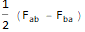

In [82]:
AntisymmetrizeIndices[{la, lb}, F[la, lb]]

In [83]:
CovD[uc, CovD[la, F[ub, lc]]]

CovD[uc, CovD[la, F[ub, lc]]]

(-CovD[uc, CovD[la, F[lc, ub]]] + CovD[uc, CovD[la, F[ub, lc]]] + 
 
>     CovD[uc, CovD[lc, F[la, ub]]] - CovD[uc, CovD[lc, F[ub, la]]] - 
 
>     CovD[uc, CovD[ub, F[la, lc]]] + CovD[uc, CovD[ub, F[lc, la]]]) / 6
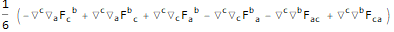

In [84]:
AntisymmetrizeIndices[{la, ub, lc}, %]

In [85]:
expr = a scalarR[] CovD[la, R[lb, lc]] F[ld, lf]

a CovD[la, R[lb, lc]] F[ld, lf] scalarR[]

(a (CovD[lb, R[ld, lc]] F[la, lf] scalarR[] - CovD[ld, R[lb, lc]] F[la, lf] scalarR[] - 
 
>       CovD[la, R[ld, lc]] F[lb, lf] scalarR[] + 
 
>       CovD[ld, R[la, lc]] F[lb, lf] scalarR[] + 
 
>       CovD[la, R[lb, lc]] F[ld, lf] scalarR[] - CovD[lb, R[la, lc]] F[ld, lf] scalarR[]
 
>       )) / 6
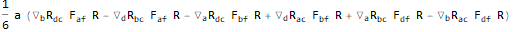

In [86]:
AntisymmetrizeIndices[{la, lb, ld}, expr]

첫 번째 인자의 인덱스들이 `HeadQs`를 만족하는 `IndexedObject`에 존재해야 한다.

In [87]:
AntisymmetrizeIndices[{la, lb, ld}, expr, 
 HeadQs -> {IndexedOperatorQ}]

`1` `2` `3` `4`: {la, lb, ld} is not subset of {la, lb, lc} 

a CovD[la, R[lb, lc]] F[ld, lf] scalarR[]

In [88]:
a R[la, lb] F[lc, ld]

a F[lc, ld] R[la, lb]

a (F[lc, ld] R[la, lb] + F[lc, ld] R[lb, la])
---------------------------------------------
                      2
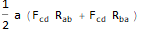

In [89]:
SymmetrizeIndices[{la, lb}, %]

In [90]:
CovD[uc, CovD[la, R[ub, lc]]]

CovD[uc, CovD[la, R[ub, lc]]]

(CovD[uc, CovD[la, R[lc, ub]]] + CovD[uc, CovD[la, R[ub, lc]]] + 
 
>     CovD[uc, CovD[lc, R[la, ub]]] + CovD[uc, CovD[lc, R[ub, la]]] + 
 
>     CovD[uc, CovD[ub, R[la, lc]]] + CovD[uc, CovD[ub, R[lc, la]]]) / 6
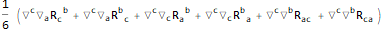

In [91]:
SymmetrizeIndices[{la, ub, lc}, %]

In [92]:
R[la, lb] F[lc, ld]

F[lc, ld] R[la, lb]

(F[lc, ld] R[la, lb] + F[lb, ld] R[la, lc] + F[lc, ld] R[lb, la] + F[la, ld] R[lb, lc] + 
 
>     F[lb, ld] R[lc, la] + F[la, ld] R[lc, lb]) / 6
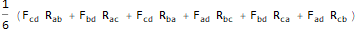

In [93]:
SymmetrizeIndices[{la, lb, lc}, %]

In [94]:
expr = CovD[la, R[lb, lc]] F[ld, lf]

CovD[la, R[lb, lc]] F[ld, lf]

(CovD[lb, R[ld, lc]] F[la, lf] + CovD[ld, R[lb, lc]] F[la, lf] + 
 
>     CovD[la, R[ld, lc]] F[lb, lf] + CovD[ld, R[la, lc]] F[lb, lf] + 
 
>     CovD[la, R[lb, lc]] F[ld, lf] + CovD[lb, R[la, lc]] F[ld, lf]) / 6
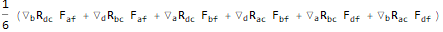

In [95]:
SymmetrizeIndices[{la, lb, ld}, expr]

In [96]:
SymmetrizeIndices[{la, ub}, Log[R[la, lb] R[ua, ub]]]

`1` `2` `3` `4`: {la, ub} is not subset of {} 

Log[R[la, lb] R[ua, ub]]

ScalarFunction의 인덱스들도 처리하려면 `HeadQs`의 옵션으로 `ObjectQ`를 이용한다:

2                               2
a (Tscalar[R[la, lb] R[ua, ub]]  + Tscalar[R[ua, la] R[ub, lb]] )
-----------------------------------------------------------------
                                2
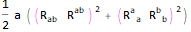

In [97]:
SymmetrizeIndices[{la, ub}, a Tscalar[R[la, lb] R[ua, ub]]^2, 
 HeadQs -> {ObjectQ}]

In [98]:
RemoveObject[{f, scalarR, R, F, CovD}]

## 3. Dum, DumFresh, and ResetDummies

In [99]:
Off[AutoFlag]

In [100]:
Tdefine[R, "ba"];
Tdefine[F, "-ba"];
Tdefine[CurvR, "R", "-bacd-abdc+cdab"];
TMP`defineOperator[CovD, "\[Del]", CD]

### 3.1 Dum

임의의 표현에서 (Kind에 부합하는) dn-up 쌍의 인덱스가 dummy 인덱스가 아니면 dummy 인덱스로 바꾼다. 옵션으로 `IndexQs`와 `HeadQs`가 있다.

In [104]:
expr = A R[la, ua] CurvR[lc, ld, uc, ud] + 
  a CovD[lA, CurvR[la, lb, uc, ud]]
  CovD[uA, CurvR[ua, ub, lc, ld]]

a CovD[lA, CurvR[la, lb, uc, ud]] + A CurvR[lc, ld, uc, ud] R[la, ua]
CovD[uA, CurvR[ua, ub, lc, ld]]

In [106]:
Dum[expr]

a CovD[lA, CurvR[la, lb, uc, ud]] + A CurvR[l$2, l$3, u$2, u$3] R[l$1, u$1]

In [107]:
Dum[expr, HeadQs -> {IndexedOperatorQ}]

a CovD[lA, CurvR[la, lb, uc, ud]] + A CurvR[lc, ld, uc, ud] R[la, ua]

In [108]:
(* Kind of R is Latin *)
Dum[expr, IndexQs -> {KindIndexQ[Capital]}]

a CovD[lA, CurvR[la, lb, uc, ud]] + A CurvR[lc, ld, uc, ud] R[la, ua]

In [110]:
Dum /@ {Log[R[lc, ld] R[uc, ud]],
         Tscalar[R[lc, ld] R[uc, ud]]^2}

2
{Log[R[lc, ld] R[uc, ud]], Tscalar[R[lc, ld] R[uc, ud]] }

ScalarFunction의 인덱스들도 고려하려면 `HeadQs`의 옵션으로 `ObjectQ`를 사용한다:

In [111]:
Dum[#, HeadQs -> {ObjectQ}] & /@ {Log[R[lc, ld] R[uc, ud]], 
  Tscalar[R[lc, ld] R[uc, ud]]^2}

2
{Log[R[l$4, l$5] R[u$4, u$5]], Tscalar[R[l$6, l$7] R[u$6, u$7]] }

올바른 텐서 곱이 아닌 경우에도 있는 그대로 바꾸므로 주의해야 한다.

In [112]:
CurvR[la, lb, ua, uc] CurvR[la, lb, ua, ud]

CurvR[la, lb, ua, uc] CurvR[la, lb, ua, ud]

In [113]:
Dum[%]

CurvR[l$8, lb, u$8, uc] CurvR[l$8, lb, u$8, ud]

### 3.2 DumFresh

임의의 표현에서 (Kind에 부합하는) dn-up 쌍의 인덱스를 새로운 dummy 인덱스로 바꾼다. 옵션으로 `IndexQs`와 `HeadQs`가 있다.

In [114]:
Dum[expr]

a CovD[lA, CurvR[la, lb, uc, ud]] + A CurvR[l$10, l$11, u$10, u$11] R[l$9, u$9]

In [115]:
DumFresh[%]

a CovD[lA, CurvR[la, lb, uc, ud]] + A CurvR[l$12, l$13, u$12, u$13] R[l$14, u$14]

In [116]:
DumFresh[expr, HeadQs -> {IndexedOperatorQ}]

a CovD[lA, CurvR[la, lb, uc, ud]] + A CurvR[lc, ld, uc, ud] R[la, ua]

In [117]:
DumFresh[expr, IndexQs -> {KindIndexQ[Capital]}]

a CovD[lA, CurvR[la, lb, uc, ud]] + A CurvR[lc, ld, uc, ud] R[la, ua]

이 함수는 `Dum` 함수와 다르게 이미 dummy인 인덱스도 새로운 dummy 인덱스로 바꾼다.

In [118]:
Dum[R[la, lb] R[ua, ub]]

R[l$15, l$16] R[u$15, u$16]

In [119]:
Dum[%]

R[l$15, l$16] R[u$15, u$16]

In [120]:
DumFresh[%]

R[l$17, l$18] R[u$17, u$18]

In [121]:
Dum[#, HeadQs -> {ObjectQ}] & /@ {Log[R[lc, ld] R[uc, ud]], 
  Tscalar[R[lc, ld] R[uc, ud]]^2}

2
{Log[R[l$19, l$20] R[u$19, u$20]], Tscalar[R[l$21, l$22] R[u$21, u$22]] }

In [122]:
DumFresh[#, HeadQs -> {ObjectQ}] & /@ %

2
{Log[R[l$23, l$24] R[u$23, u$24]], Tscalar[R[l$25, l$26] R[u$25, u$26]] }

### 3.3 ResetDummies

임의의 표현에 있는 dummy 인덱스들을 순차적으로 재조정한다. 프로그램이 생성한 dummy 인덱스의 경우 인덱스 숫자값은 프로그램을 사용하는 동안 유일한 값을 가지므로 재조정된 표현과 다른 표현을 섞어서 사용하면 잘못된 결과가 생길 수도 있다. 옵션으로는 `IndexQs`와 `HeadQs`가 있다. 그리고 프로그램이 생성한 dummy 인덱스뿐만이 아닌 모든 contraction된 인덱스들을 `IndexedObject`의 kind와 무관하게 다시 조정하려면 옵션으로 `All -> True`를 입력하거나 `Options[ResetDummies]`를 조정한다. 또한 대치되는 인덱스들을 조정하려면 옵션으로 `Dummy -> "indices"`를 사용한다.

In [123]:
expr = A R[la, ua] CurvR[lc, ld, uc, ud] + 
  a CovD[lB, CurvR[la, lb, uc, ud]]
  CovD[uB, CurvR[ua, ub, lc, ld]]

a CovD[lB, CurvR[la, lb, uc, ud]] + A CurvR[lc, ld, uc, ud] R[la, ua]
CovD[uB, CurvR[ua, ub, lc, ld]]

In [125]:
expr = Dum[expr]

a CovD[lB, CurvR[la, lb, uc, ud]] + A CurvR[l$28, l$29, u$28, u$29] R[l$27, u$27]

In [126]:
ResetDummies[expr]

a CovD[lB, CurvR[la, lb, uc, ud]] + A CurvR[la, lb, ua, ub] R[lc, uc]

In [127]:
ResetDummies[expr, All -> True]  (* including Capital indices *)

a CovD[lB, CurvR[la, lb, uc, ud]] + A CurvR[la, lb, ua, ub] R[lc, uc]

In [128]:
ResetDummies[expr, HeadQs -> {IndexedOperatorQ}]

a CovD[lB, CurvR[la, lb, uc, ud]] + A CurvR[l$28, l$29, u$28, u$29] R[l$27, u$27]

In [129]:
expr = expr + R[lp, up]

a CovD[lB, CurvR[la, lb, uc, ud]] + A CurvR[l$28, l$29, u$28, u$29] R[l$27, u$27] + 
 
>   R[lp, up]

In [130]:
ResetDummies[expr, IndexQs -> {KindIndexQ[Capital]}]

a CovD[lB, CurvR[la, lb, uc, ud]] + A CurvR[l$28, l$29, u$28, u$29] R[l$27, u$27] + 
 
>   R[lp, up]

In [131]:
ResetDummies[expr, All -> True]

a CovD[lB, CurvR[la, lb, uc, ud]] + R[la, ua] + A CurvR[la, lb, ua, ub] R[lc, uc]

In [132]:
ResetDummies[expr, Dummy -> "ZOA"]  (* Danger! *)

a CovD[lB, CurvR[la, lb, uc, ud]] + A CurvR[lZ, lO, uZ, uO] R[lA, uA] + R[lp, up]

In [133]:
Dum[#, HeadQs -> {ObjectQ}] & /@ {Log[R[lc, ld] R[uc, ud]], 
  Tscalar[R[lc, ld] R[uc, ud]]^2}

2
{Log[R[l$30, l$31] R[u$30, u$31]], Tscalar[R[l$32, l$33] R[u$32, u$33]] }

In [134]:
% // ResetDummies

2
{Log[R[l$30, l$31] R[u$30, u$31]], Tscalar[R[l$32, l$33] R[u$32, u$33]] }

In [135]:
% // ResetDummies[#, HeadQs -> {ObjectQ}] &

2
{Log[R[la, lb] R[ua, ub]], Tscalar[R[la, lb] R[ua, ub]] }

In [136]:
RemoveObject[{R, F, CurvR, CovD}]

## 4. SumDum

인자로 주어진 인덱스들을 이용하여 인덱스 쌍들을 다른 인덱스들로 각각 대치하고 그 결과를 합한다.

In [137]:
Off[AutoFlag]

In [138]:
Tdefine[R, "ba"];
Tdefine[CR[lA, lB]];
Tdefine[g, "ba"];
Tdefine[CurvR, "R", "-bacd-abdc+cdab"];
TMP`defineOperator[CovD, "D", CD]

### 4.1 Numeric Summation

첫 번째 인자로 주어진 인덱스 리스트들이 모두 숫자인 경우 두 번째 인자에 있는 표현의 인덱스 쌍들을 첫 번째 숫자부터 나중 숫자까지 1씩 증가시키면서 순차적으로 대치시킨 후에 합한다. 옵션으로는 `HeadQs`가 있다.

In [143]:
expr = a R[la, ua] R[lb, ub] CovD[lA, R[l\[Mu], uA]] CR[lB, uB]

a CovD[lA, R[lμ, uA]] CR[lB, uB] R[la, ua] R[lb, ub]

In [144]:
SumDum[{1, 3}, expr]  (* pairs in DefaultKind *)

2
a (CovD[lA, R[lμ, uA]] CR[lB, uB] R[-3, 3]  + 
 
>     2 CovD[lA, R[lμ, uA]] CR[lB, uB] R[-3, 3] R[-2, 2] + 
 
                                             2
>     CovD[lA, R[lμ, uA]] CR[lB, uB] R[-2, 2]  + 
 
>     2 CovD[lA, R[lμ, uA]] CR[lB, uB] R[-3, 3] R[-1, 1] + 
 
>     2 CovD[lA, R[lμ, uA]] CR[lB, uB] R[-2, 2] R[-1, 1] + 
 
                                             2
>     CovD[lA, R[lμ, uA]] CR[lB, uB] R[-1, 1] )

In [145]:
SumDum[{1, 3}, expr, HeadQs -> {IndexedOperandQ}]

2
a CovD[lA, R[lμ, uA]] (CR[lB, uB] R[-3, 3]  + 2 CR[lB, uB] R[-3, 3] R[-2, 2] + 
 
                         2
>     CR[lB, uB] R[-2, 2]  + 2 CR[lB, uB] R[-3, 3] R[-1, 1] + 
 
                                                          2
>     2 CR[lB, uB] R[-2, 2] R[-1, 1] + CR[lB, uB] R[-1, 1] )

세 번째 인자로 kind를 입력하면 그 kind에 속한 `IndicalObject`의 Dummy 인덱스들만 고려된다:

In [146]:
SumDum[{1, 3}, expr, Capital]

a (CovD[lA, R[lμ, uA]] CR[-3, 3] R[la, ua] R[lb, ub] + 
 
>     CovD[lA, R[lμ, uA]] CR[-2, 2] R[la, ua] R[lb, ub] + 
 
>     CovD[lA, R[lμ, uA]] CR[-1, 1] R[la, ua] R[lb, ub])

In [147]:
SumDum[{1, 3}, expr, Capital, HeadQs -> {IndexedOperandQ}]

a CovD[lA, R[lμ, uA]] (CR[-3, 3] R[la, ua] R[lb, ub] + CR[-2, 2] R[la, ua] R[lb, ub] + 
 
>     CR[-1, 1] R[la, ua] R[lb, ub])

In [148]:
SumDum[{1, 2}, a Log[R[lA, lb] R[uA, ub]]]

a Log[R[lA, lb] R[uA, ub]]

In [149]:
(* Don't SumDum for ScalarFunctions *)
SumDum[{1, 2}, a Log[R[lA, lb] R[uA, ub]], HeadQs -> {ObjectQ}]

a Log[R[lA, lb] R[uA, ub]]

잘못된 텐서 표현도 있는 그대로 바꾸므로 주의해야 한다.

In [151]:
SumDum[{1, 2}, R[la, ua] g[la, lb]]

g[-2, lb] R[-2, 2] + g[-1, lb] R[-1, 1]

### 4.2 Component mode

`Dimension`의 값이 정수일 때 인덱스 쌍들을 component 인덱스로 대치하고 각각을 합한다. 두 번째 인자로 kind가 입력되지 않는한 `DefaultKind`의 인덱스만 고려된다. 옵션으로는 `HeadQs`가 있다.

In [152]:
GetDimension[DefaultKind] = 2;

In [153]:
SumDum[g[la, ua]]

g[-2, 2] + g[-1, 1]

In [154]:
expr = {CovD[la, R[lb, ua]], g[la, ua]}

{CovD[la, R[lb, ua]], g[la, ua]}

In [155]:
SumDum[#, HeadQs -> {IndexedOperandQ}] & /@ expr

{CovD[la, R[lb, ua]], g[-2, 2] + g[-1, 1]}

In [156]:
SumDum[#, HeadQs -> {IndexedOperatorQ}] & /@ expr

{CovD[-2, R[lb, 2]] + CovD[-1, R[lb, 1]], g[la, ua]}

In [157]:
GetDimension[Capital] = 3;

In [158]:
SumDum[g[la, ua] CR[lA, uA]]

CR[lA, uA] g[-2, 2] + CR[lA, uA] g[-1, 1]

In [159]:
SumDum[g[la, ua] CR[lA, uA], Capital]

CR[-3, 3] g[la, ua] + CR[-2, 2] g[la, ua] + CR[-1, 1] g[la, ua]

In [160]:
{Log[R[la, lb] R[ua, ub]], Tscalar[R[la, lb] R[ua, ub]]^2}

2
{Log[R[la, lb] R[ua, ub]], Tscalar[R[la, lb] R[ua, ub]] }

In [161]:
SumDum[#, HeadQs -> {ObjectQ}] & /@ %

2
{Log[R[la, lb] R[ua, ub]], Tscalar[R[la, lb] R[ua, ub]] }

In [162]:
GetDimension[Latin] =.;

In [163]:
SumDum[g[la, ua]]

`1` `2` `3` `4`: Component mode of SumDum requires Dimension for Latin Use SetDimension. 

g[la, ua]

In [164]:
GetDimension[Capital] =.;

### 4.3 Symbolic Summation

첫 번째 인자 리스트의 처음 요소에 해당하는 인덱스 쌍들을 다음부터 끝까지의 요소에 해당하는 인덱스들로 각각 대치하고 그 결과를 합한다. 옵션으로는 `HeadQs`가 있다.

Symbolic 모드에서는 `IndexedObject`의 kind가 고려되지 않는다. 즉 `IndexedObject`의 정의에 사용된 인덱스의 kind는 무시하고, indexed exprs의 모든(All) contracted 인덱스가 고려된다. 따라서 텐서 표현의 인덱스에 대한 타당성은 사용자의 몫이다.

In [165]:
expr = a R[la, ua] R[lb, ub] CovD[lA, R[l\[Mu], uA]] CR[lB, uB]

a CovD[lA, R[lμ, uA]] CR[lB, uB] R[la, ua] R[lb, ub]

In [166]:
SumDum[{la, li, lj}, expr]

a (CovD[lA, R[lμ, uA]] CR[lB, uB] R[lb, ub] R[li, ui] + 
 
>     CovD[lA, R[lμ, uA]] CR[lB, uB] R[lb, ub] R[lj, uj])

In [167]:
(* Although the kind of CovD is Latin,
  the considered indices are {lA,uA}. *)
SumDum[{lA, -1, -2, li, lj}, expr]

a (CovD[-2, R[lμ, 2]] CR[lB, uB] R[la, ua] R[lb, ub] + 
 
>     CovD[-1, R[lμ, 1]] CR[lB, uB] R[la, ua] R[lb, ub] + 
 
>     CovD[li, R[lμ, ui]] CR[lB, uB] R[la, ua] R[lb, ub] + 
 
>     CovD[lj, R[lμ, uj]] CR[lB, uB] R[la, ua] R[lb, ub])

In [169]:
SumDum[{la, -1, -2, li, lj}, expr]

a (CovD[lA, R[lμ, uA]] CR[lB, uB] R[-2, 2] R[lb, ub] + 
 
>     CovD[lA, R[lμ, uA]] CR[lB, uB] R[-1, 1] R[lb, ub] + 
 
>     CovD[lA, R[lμ, uA]] CR[lB, uB] R[lb, ub] R[li, ui] + 
 
>     CovD[lA, R[lμ, uA]] CR[lB, uB] R[lb, ub] R[lj, uj])

In [170]:
SumDum[{la, -1, -2, li, lj}, expr, HeadQs -> {IndexedOperandQ}]

a CovD[lA, R[lμ, uA]] (CR[lB, uB] R[-2, 2] R[lb, ub] + CR[lB, uB] R[-1, 1] R[lb, ub] + 
 
>     CR[lB, uB] R[lb, ub] R[li, ui] + CR[lB, uB] R[lb, ub] R[lj, uj])

In [171]:
(* NB: Kind of R is Latin *)
SumDum[{lA, l\[Mu], li}, {lB, l\[Nu], lj}, R[lA, lB] R[uA, uB]]

R[li, lj] R[ui, uj] + R[li, lν] R[ui, uν] + R[lμ, lj] R[uμ, uj] + R[lμ, lν] R[uμ, uν]

In [173]:
SumDum[{la, l\[Mu], li}, {lb, l\[Nu], lj}, R[la, lb] R[ua, ub]]

R[li, lj] R[ui, uj] + R[li, lν] R[ui, uν] + R[lμ, lj] R[uμ, uj] + R[lμ, lν] R[uμ, uν]

CurvR[la, lb, lc, ld] CurvR[ua, ub, uc, ud] + 
 
>   CurvR[la, lb, lc, lσ] CurvR[ua, ub, uc, uσ] + 
 
>   CurvR[la, lb, lρ, ld] CurvR[ua, ub, uρ, ud] + 
 
>   CurvR[la, lb, lρ, lσ] CurvR[ua, ub, uρ, uσ] + 
 
>   CurvR[la, lν, lc, ld] CurvR[ua, uν, uc, ud] + 
 
>   CurvR[la, lν, lc, lσ] CurvR[ua, uν, uc, uσ] + 
 
>   CurvR[la, lν, lρ, ld] CurvR[ua, uν, uρ, ud] + 
 
>   CurvR[la, lν, lρ, lσ] CurvR[ua, uν, uρ, uσ] + 
 
>   CurvR[lμ, lb, lc, ld] CurvR[uμ, ub, uc, ud] + 
 
>   CurvR[lμ, lb, lc, lσ] CurvR[uμ, ub, uc, uσ] + 
 
>   CurvR[lμ, lb, lρ, ld] CurvR[uμ, ub, uρ, ud] + 
 
>   CurvR[lμ, lb, lρ, lσ] CurvR[uμ, ub, uρ, uσ] + 
 
>   CurvR[lμ, lν, lc, ld] CurvR[uμ, uν, uc, ud] + 
 
>   CurvR[lμ, lν, lc, lσ] CurvR[uμ, uν, uc, uσ] + 
 
>   CurvR[lμ, lν, lρ, ld] CurvR[uμ, uν, uρ, ud] + 
 
>   CurvR[lμ, lν, lρ, lσ] CurvR[uμ, uν, uρ, uσ]
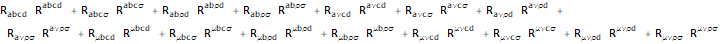

In [174]:
SumDum[{li, l\[Mu], la}, {lj, l\[Nu], lb}, {lk, l\[Rho], lc},
        {ll, l\[Sigma], ld},
        CurvR[li, lj, lk, ll] CurvR[ui, uj, uk, ul]]

In [175]:
SumDum[{lA, l\[Mu], li}, R[uA, lA]]

R[ui, li] + R[uμ, lμ]

대치되는 것들이 합당하지 않은 인덱스일 수 있다: 

In [176]:
SumDum[{la, l\[Mu], li}, {lb, lba, no}, R[ua, la] R[ub, lb]]

R[no, no] R[ui, li] + R[uba, lba] R[ui, li] + R[no, no] R[uμ, lμ] + R[uba, lba] R[uμ, lμ]

인자로 주어진 인덱스가 operand에 없으면 경고 메세지가 발생된다.

In [177]:
SumDum[{la, l\[Mu], li}, {lb, l\[Nu], lj}, R[uA, lA]]

`1` `2` `3` `4`: no compatible index: la in R[uA, lA]

`1` `2` `3` `4`: no compatible index: lb in R[uA, lA]

R[uA, lA]

In [178]:
SumDum[{la, li, lj}, a Tscalar[Log[R[la, lb] R[ua, ub]]]]

`1` `2` `3` `4`: no compatible index: la in 1

a Log[R[la, lb] R[ua, ub]]

In [179]:
(* Don't SumDum for ScalarFunctions *)
SumDum[{la, li, lj}, a Log[R[la, lb] R[ua, ub]],
        HeadQs -> {ObjectQ}]

`1` `2` `3` `4`: no compatible index: la in 1

a Log[R[la, lb] R[ua, ub]]

## 5. RuleUnique and DefUnique

In [181]:
Off[AutoFlag]

In [182]:
(* See MathTensor Book! *)
Tdefine[{f[], g[], h[]}]; Tdefine[{a, b, c}, "a"]

### 5.1 RuleUnique

Dummy 인덱스를 고려한 rule을 얻기 위한 함수이다. 첫 번째와 두 번째 인자는 각각 rule의 왼쪽 표현과 오른쪽 표현이고, option으로 세 번째 인자는 rule의 조건이 될 수 있다. 돌려주는 rule의 형태는 `lhs :> DumFresh[rhs] /; cond` 형태이다.

In [184]:
aRule = RuleUnique[b[la_, ub_], a[la] a[ub] a[lc] a[uc],
                     PairIndexQ[{la, ub}]]

b[la_, ub_] :> DumFresh[a[l$34] a[u$34] a[la] a[ub]] /; PairIndexQ[{la, ub}]

In [185]:
expr1 = b[la, ua] b[lb, ub]

b[la, ua] b[lb, ub]

In [186]:
expr1 /. aRule 

a[l$35] a[l$36] a[l$37] a[l$38] a[u$35] a[u$36] a[u$37] a[u$38]

In [187]:
bRule = RuleUnique[c[la_, lb_], 2 b[la, lb]]

c[la_, lb_] :> DumFresh[2 b[la, lb]]

In [188]:
rules = {aRule, bRule};

In [189]:
rc = c[la, ua] c[lb, ub] /. rules

4 b[la, ua] b[lb, ub]

In [190]:
rc /. rules 

4 a[l$39] a[l$40] a[l$41] a[l$42] a[u$39] a[u$40] a[u$41] a[u$42]

In [191]:
c[la, ua] c[lb, ub] //. rules

4 a[l$43] a[l$44] a[l$45] a[l$46] a[u$43] a[u$44] a[u$45] a[u$46]

`Rule`의 오른쪽 표현 (rhs) 에 `IndexedObject`가 아닌 ScalarFunction들이 있는 경우는 Dummy 인덱스에 문제가 발생할 수 있다. 이 경우에는 `HeadQs` 옵션을 조정한다:

In [192]:
Options[HeadQs]

{HeadQs -> {IndexedObjectQ}}

In [193]:
aRule = RuleUnique[b[la_, ub_], a[la] a[ub] Tscalar[a[lc] a[uc]],
                    PairIndexQ[{la, ub}]]

b[la_, ub_] :> DumFresh[a[la] a[ub] Tscalar[a[lc] a[uc]]] /; PairIndexQ[{la, ub}]

In [194]:
b[la, ua] b[lb, ub] /. aRule 

2
a[l$47] a[l$48] a[u$47] a[u$48] Tscalar[a[lc] a[uc]]

In [195]:
Options[HeadQs] = {HeadQs -> {ObjectQ}};

In [196]:
aRule = RuleUnique[b[la_, ub_], a[la] a[ub] Tscalar[a[lc] a[uc]],
                    PairIndexQ[{la, ub}]]

b[la_, ub_] :> DumFresh[a[la] a[ub] Tscalar[a[l$49] a[u$49]]] /; PairIndexQ[{la, ub}]

In [197]:
b[la, ua] b[lb, ub] /. aRule 

a[l$51] a[l$53] a[u$51] a[u$53] Tscalar[a[l$50] a[u$50]] Tscalar[a[l$52] a[u$52]]

In [198]:
Options[HeadQs] = {HeadQs -> {IndexedObjectQ}};(* default *)

In [199]:
cRule = RuleUnique[f[], b[la, lb] b[ua, ub]]

f[] :> DumFresh[b[l$54, lb] b[u$54, ub]]

In [200]:
f[] b[la, ua] /. {aRule, cRule} 

a[l$55] a[u$55] b[l$56, lb] b[u$56, ub] Tscalar[a[l$49] a[u$49]]

In [201]:
{Log[f[]], Tscalar[f[] g[]]^2} /. cRule

2
{Log[b[l$57, lb] b[u$57, ub]], Tscalar[b[l$58, lb] b[u$58, ub] g[]] }

### 5.2 DefUnique

Dummy 인덱스를 고려하여 한 표현을 다른 Object에 대입하기 위한 함수이다. 첫 번째와 두 번째 인자는 각각 대입을 위한 왼쪽 표현과 오른쪽 표현이고, option으로 세 번째 인자는 조건이 될 수 있다.

In [202]:
DefUnique[b[la_, lb_], a[la] a[lb] a[lc] a[uc],
           PairIndexQ[la, lb]]

In [203]:
b[la, lb]

b[la, lb]

In [204]:
b[la, ua]

a[l$60] a[l$61] a[u$60] a[u$61]

In [205]:
DefUnique[c[la_, lb_], 2 b[la, lb]]

In [206]:
c[la, lb]

2 b[la, lb]

In [207]:
c[la, ua]

2 a[l$64] a[l$65] a[u$64] a[u$65]

In [208]:
c[la, ua] b[lb, ub]

2 a[l$68] a[l$69] a[l$70] a[l$71] a[u$68] a[u$69] a[u$70] a[u$71]

In [209]:
DefUnique[h[], b[la, ua] b[lb, ub]]

In [210]:
h[]

a[l$76] a[l$77] a[l$78] a[l$79] a[u$76] a[u$77] a[u$78] a[u$79]

In [211]:
{Log[h[]], h[]^2, Tscalar[h[]]^2}

{Log[a[l$80] a[l$81] a[l$82] a[l$83] a[u$80] a[u$81] a[u$82] a[u$83]], 
 
           2        2        2        2        2        2        2        2
>   a[l$84]  a[l$85]  a[l$86]  a[l$87]  a[u$84]  a[u$85]  a[u$86]  a[u$87] , 
 
                                                                            2
>   Tscalar[a[l$88] a[l$89] a[l$90] a[l$91] a[u$88] a[u$89] a[u$90] a[u$91]] }

In [212]:
RemoveObject[{h, a, b, c, f, g}]

## 6. SyntexCheck

입력된 표현이 적당한 텐서 표현인가를 알아보는 함수이다. 옵션으로 `HeadQs`가 있다. 적당하지 않은 표현에 대해서는 `EerrorT` 표현값을 돌려 준다.

In [213]:
Off[AutoFlag]

In [214]:
Tdefine[scrR[], "R"];
Tdefine[F[la, lb], "-ba"];
Tdefine[R[la, lb], "ba"];
Tdefine[\[Epsilon], "*-"];
TMP`defineOperator[CovD, "\[Del]", CD];
TMP`defineOperator[LieD, "\[ScriptCapitalL]", LD]

### 6.1 Free Indices

텐서 합의 free indices는 동일해야 한다.

In [220]:
a scrR[] F[lb, ua] + b R[lb, la]

b R[lb, la] + a F[lb, ua] scrR[]

In [221]:
SyntaxCheck[%]

`1` `2` `3` `4`: incompatible free indices: {lb, la} and {lb, ua}

ErrorT[b R[lb, la] + a F[lb, ua] scrR[]]

### 6.2 Duplicated Indices

텐서 표현에서 동일한 인덱스는 허용되지 않는다.

In [222]:
R[la, la]

R[la, la]

In [223]:
SyntaxCheck[%]

`1` `2` `3` `4`: duplicated indices: {la, la}  

ErrorT[R][la, la]

In [224]:
R[la, lb] F[lb, la]

F[lb, la] R[la, lb]

In [225]:
SyntaxCheck[%]

`1` `2` `3` `4`: duplicated indices: {lb, la, la, lb}  

ErrorT[F[lb, la] R[la, lb]]

In [226]:
CovD[la, R[lb, lc] R[lc, lb]]

CovD[la, R[lb, lc] R[lc, lb]]

In [227]:
SyntaxCheck[%]

`1` `2` `3` `4`: duplicated indices: {lb, lc, lc, lb}  

CovD[la, ErrorT[R[lb, lc] R[lc, lb]]]

In [228]:
SyntaxCheck[CovD[la, R[lb, uc] R[lc, lb]],
             HeadQs -> {IndexedOperandQ}]

CovD[la, R[lb, uc] R[lc, lb]]

### 6.3 Number of Indices

텐서 인덱스의 수는 그 텐서의 rank와 같아야 한다.

In [229]:
R[la]

R[la]

In [230]:
SyntaxCheck[%]

`1` `2` `3` `4`: invalid number of indices for R :  {la}

ErrorT[R][la]

임의의 rank를 갖는 텐서

In [231]:
SyntaxCheck /@ {\[Epsilon][], \[Epsilon][la], \[Epsilon][la, lb],
                 \[Epsilon][la, lb, lc]}

`1` `2` `3` `4`: invalid number of indices for Ïµ  

{ErrorT[ϵ][], ϵ[la], ϵ[la, lb], ϵ[la, lb, lc]}

### 6.4 Kind

인덱스 계열이 고려된다.

In [232]:
R[la, lB]

R[la, lB]

In [233]:
SyntaxCheck[%]

`1` is not a valid `2`.: lB is not a valid index.

ErrorT[R][la, lB]

In [234]:
CovD[lA, R[la, lc]] R[lc, ld]

CovD[lA, R[la, lc]] R[lc, ld]

In [235]:
SyntaxCheck[%]

`1` is not a valid `2`.: lA is not a valid index.

R[lc, ld] ErrorT[CovD][lA, R[la, lc]]

### 6.5 Dnup

In [236]:
Off[MetricgFlag]

Kind가 `MetricSpaceQ`를 만족하지 않는 경우 인덱스는 `IndexedObject`의 정의에서 결정된 dn/up을 만족해야 한다.

In [237]:
{R[la, lb], R[la, ub]} // SyntaxCheck

`1` `2` `3` `4`: R has wrong-dn/up: {la, ub} 

{R[la, lb], ErrorT[R][la, ub]}

CD-type 연산자의 첫 번째 인자는 dn 인덱스이다:

In [238]:
{CovD[la, R[lb, lc]], CovD[ua, R[lb, lc]]} // SyntaxCheck

`1` `2` `3` `4`: The index of CovD is not down: ua

{CovD[la, R[lb, lc]], ErrorT[CovD][ua, R[lb, lc]]}

In [239]:
On[MetricgFlag]  (* default *)

### 6.6 Operator

In [240]:
LieD[V[la], R[la, lb]]

LieD[V[la], R[la, lb]]

In [241]:
SyntaxCheck[%]

`1` `2` `3` `4`: non-symbolic argument V[la] for an operator LieD

ErrorT[LieD][V[la], R[la, lb]]

### 6.7 ScalarFunction

In [242]:
Log[R[la, la]]

Log[R[la, la]]

In [243]:
SyntaxCheck[%]

`1` `2` `3` `4`: duplicated indices: {la, la}  

Log[ErrorT[R][la, la]]

In [244]:
R[la, lb]^2

2
R[la, lb]

In [245]:
SyntaxCheck[%]

`1` `2` `3` `4`: non-scalar expression R[la, lb]  

ErrorT[Power][R[la, lb], 2]

In [246]:
Log[R[la, lb] R[ld, lc]]

Log[R[la, lb] R[ld, lc]]

In [247]:
SyntaxCheck[%]

`1` `2` `3` `4`: non-scalar expression R[la, lb] R[ld, lc]  

ErrorT[Log][R[la, lb] R[ld, lc]]

## 7. On/Off

In [248]:
Tdefine[f[]];
Tdefine[F[la, lb], "-ba"];
Tdefine[R[la, lb], "ba"];
Tdefine[R4[la], "abcd"];
TMP`defineOperator[CovD, "\[Del]", CD];

### 7.1 AutoFlag

출력 표현을 자동적으로 조정하려면 On 시키고, 그렇지 않으면 Off 시킨다. 이것을 On 시키면 `SyntaxCheckFlag`이 On인 경우의 문법 검사, `ResetDummiesFlag`이 On인 경우의 dummy 인덱스 재조정이 자동적으로 이루어 진다. 따라서 `AutoFlag`은 비록 연산 효율이 떨어지지만 On 시키는 것이 좋다. Default는 On이다.

In [253]:
Off[AutoFlag]

In [254]:
F[la, ua] // Dum

F[l$92, u$92]

In [255]:
On[AutoFlag]

In [256]:
F[la, ua] // Dum

F[la, ua]

### 7.2 MarkErrorFlag

텐서 인덱스 등에 오류가 있음을 발견했을 때 자동적으로 `ErrorT` 심볼로 그 텐서를 둘러 싸려면 On 시키고, 그렇지 않으면 Off 시킨다. 이것을 On 시켜도 `AutoFlag`이 Off이면 아무런 효과가 없으므로 `AutoFlag`도 On 시켜야 한다. Default는 On이다.

In [257]:
Off[MarkErrorFlag]

In [258]:
{F[lb, lb], F[la, ub]}

{F[lb, lb], F[la, ub]}

In [259]:
On[MarkErrorFlag]

In [260]:
{F[lb, lb], F[la, ub]} // SyntaxCheck

`1` `2` `3` `4`: duplicated indices: {lb, lb}  

{ErrorT[F][lb, lb], F[la, ub]}

### 7.3 ResetDummiesFlag

`AutoFlag`에 의한 출력 표현에 `ResetDummies` 함수를 작용시켜 dummy 인덱스들을 자동적으로 재조정하려면 On 시키고, 그렇지 않으면 Off 시킨다. 이것을 On 시켜도 `AutoFlag`이 Off이면 출력에 대한 자동적인 재조정에 아무런 효과가 없으므로 `AutoFlag`도 On 시켜야 한다. Default는 On이다.

In [261]:
Off[ResetDummiesFlag]

In [262]:
Dum[R[la, lb] R[ua, ub]] // DumFresh

R[l$96, l$97] R[u$96, u$97]

In [263]:
On[AutoFlag]

In [264]:
On[ResetDummiesFlag]

In [265]:
Dum[R[la, lb] R[ua, ub]] // DumFresh

R[la, lb] R[ua, ub]

### 7.4 SyntaxCheckFlag

임의의 표현이 텐서 표현으로 적당한가를 자동적으로 검사하려면 On 시키고, 그렇지 않으면 Off 시킨다. 이것을 On 시켜도 `AutoFlag`이 Off이면 아무런 효과가 없으므로 `AutoFlag`도 On 시켜야 한다. Default는 Off이다.

In [266]:
On[AutoFlag]

In [267]:
On[SyntaxCheckFlag]

In [268]:
R[lb, la] R[lc, lb]

`1` `2` `3` `4`: duplicated indices: {lb, la, lc, lb}  

ErrorT[R[lb, la] R[lc, lb]]

In [269]:
CovD[la, R[lb, la] R[lc, lb]]

`1` `2` `3` `4`: duplicated indices: {lb, la, lc, lb}  

CovD[la, ErrorT[R[lb, la] R[lc, lb]]]

In [270]:
Off[SyntaxCheckFlag]

In [271]:
CovD[la, R[lb, uc] R[lc, lb]]

CovD[la, R[lb, uc] R[lc, lb]]

In [272]:
R[lb, uc] R[lc, lb]

R[lb, uc] R[lc, lb]